In [1]:
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
# بارگذاری داده CIFAR-10
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

In [3]:
# ترکیب کل داده ها (train + test)
x_all = np.concatenate((x_train, x_test), axis=0)
y_all = np.concatenate((y_train, y_test), axis=0).flatten()

In [4]:
# اسامی کلاس‌ها
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

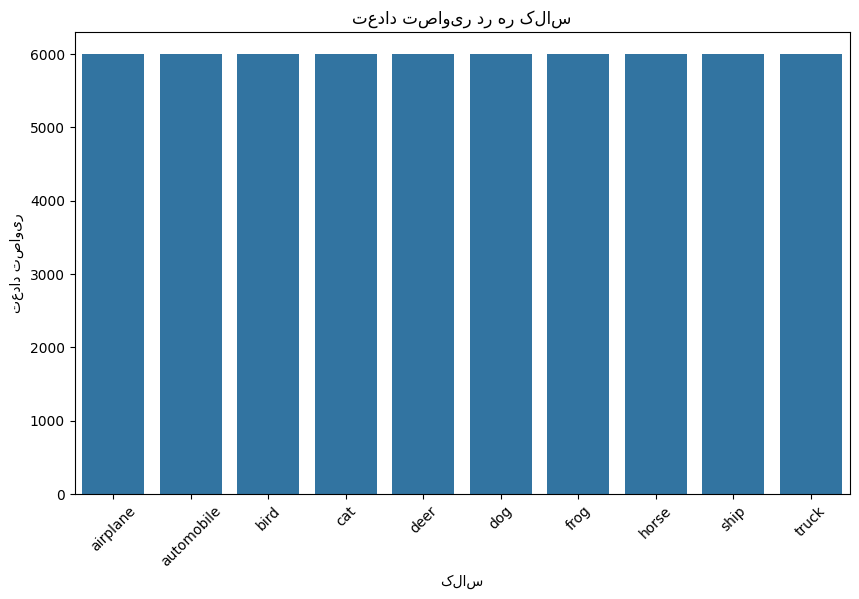

In [5]:
### 1- نمایش تعداد تصاویر در هر کلاس
class_counts = pd.Series(y_all).value_counts().sort_index()
plt.figure(figsize=(10,6))
sns.barplot(x=class_names, y=class_counts.values)
plt.title('تعداد تصاویر در هر کلاس')
plt.xlabel('کلاس')
plt.ylabel('تعداد تصاویر')
plt.xticks(rotation=45)
plt.show()

In [6]:
### 2- محاسبه میانگین، واریانس، چولگی و کشیدگی پیکسل‌ها برای هر کانال رنگی
# جدا کردن کانال‌ها
r_channel = x_all[:,:,:,0]
g_channel = x_all[:,:,:,1]
b_channel = x_all[:,:,:,2]

In [10]:
# ساخت دیتافریم خلاصه آماری
import scipy.stats as stats

summary = {}
for color, channel in zip(['Red', 'Green', 'Blue'], [r_channel, g_channel, b_channel]):
    flat = channel.flatten()
    summary[color] = {
        'میانگین': np.mean(flat),
        'واریانس': np.var(flat),
        'چولگی': stats.skew(flat),
        'کشیدگی': stats.kurtosis(flat)
    }

summary_df = pd.DataFrame(summary)
print(summary_df)

                 Red        Green         Blue
میانگین   125.426539   123.076746   114.030206
واریانس  3966.185615  3851.962383  4449.705189
چولگی       0.118547     0.164506     0.388755
کشیدگی     -0.773513    -0.718915    -0.803610


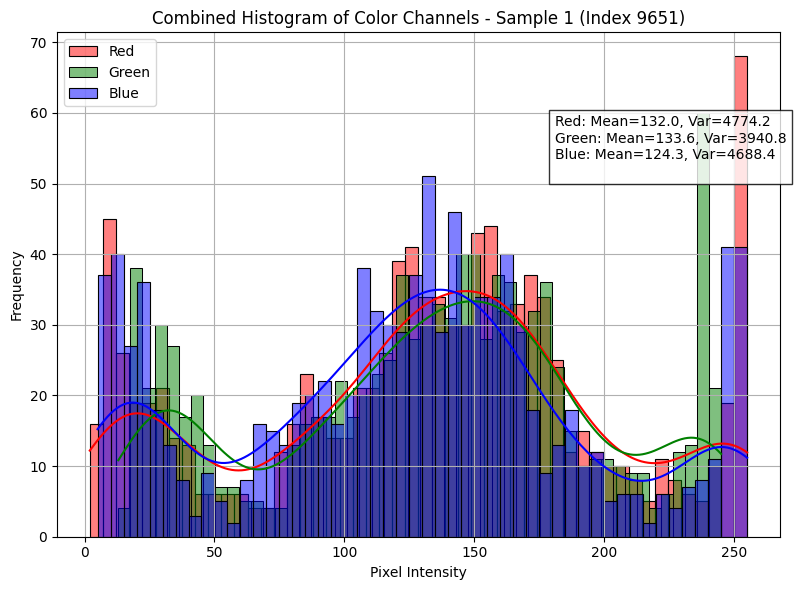

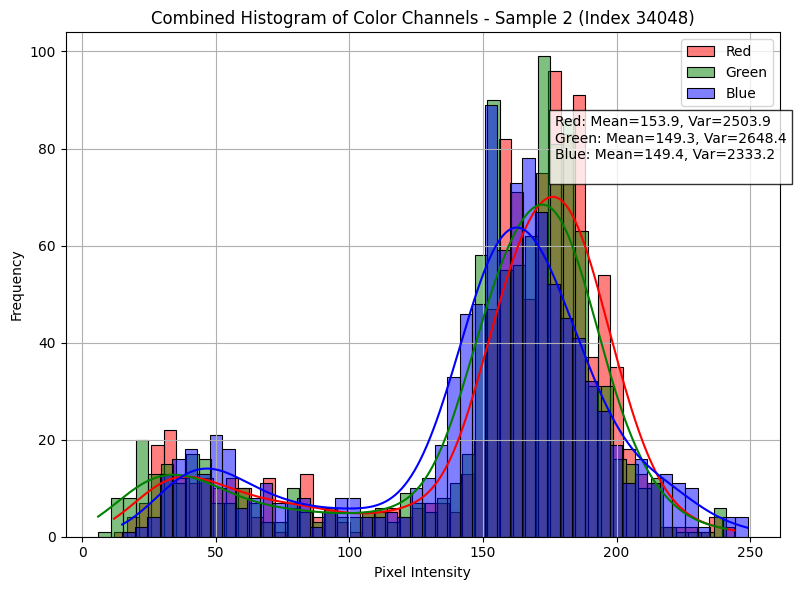

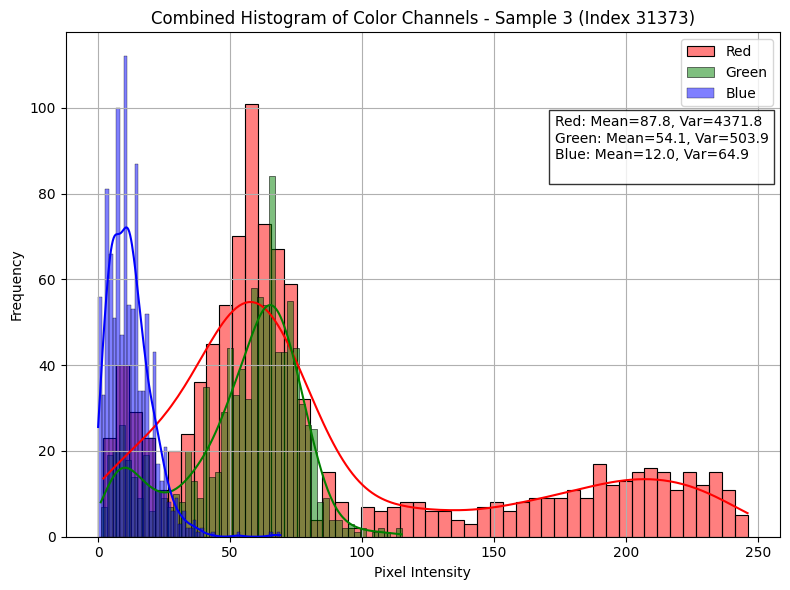

In [17]:
# -------------------------------
# بخش 3: رسم هیستوگرام شدت پیکسل‌ها برای چند تصویر (با خلاصه آماری روی نمودار)
# -------------------------------

# انتخاب چند نمونه تصویر تصادفی
sample_indices = np.random.choice(len(x_all), size=3, replace=False)
sample_images = x_all[sample_indices]

# رسم هیستوگرام سه کانال روی یک نمودار برای هر تصویر
for idx, sample_idx in enumerate(sample_indices):
    img = x_all[sample_idx]
    plt.figure(figsize=(8,6))
    
    stats_text = ""
    colors = ['Red', 'Green', 'Blue']
    
    for i, color in enumerate(colors):
        channel_data = img[:,:,i].flatten()
        sns.histplot(channel_data, bins=50, color=color.lower(), kde=True, label=color, alpha=0.5)
        
        # محاسبه خلاصه آماری
        mean_val = np.mean(channel_data)
        var_val = np.var(channel_data)
        
        # اضافه کردن به متن خلاصه
        stats_text += f"{color}: Mean={mean_val:.1f}, Var={var_val:.1f}\n"
    
    plt.title(f'Combined Histogram of Color Channels - Sample {idx+1} (Index {sample_idx})')
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(True)
    
    # اضافه کردن خلاصه آماری روی نمودار
    plt.gcf().text(0.7, 0.7, stats_text, fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()


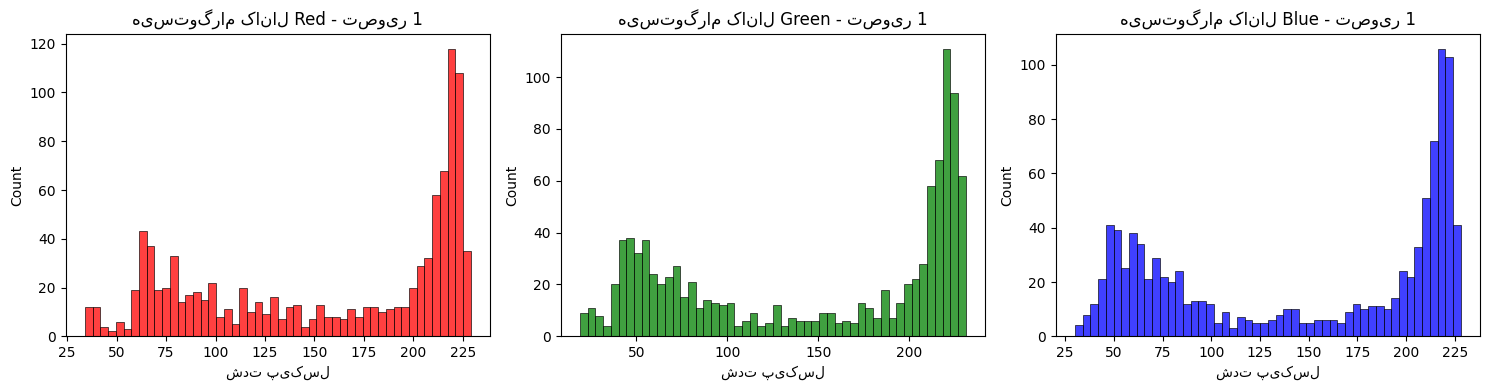

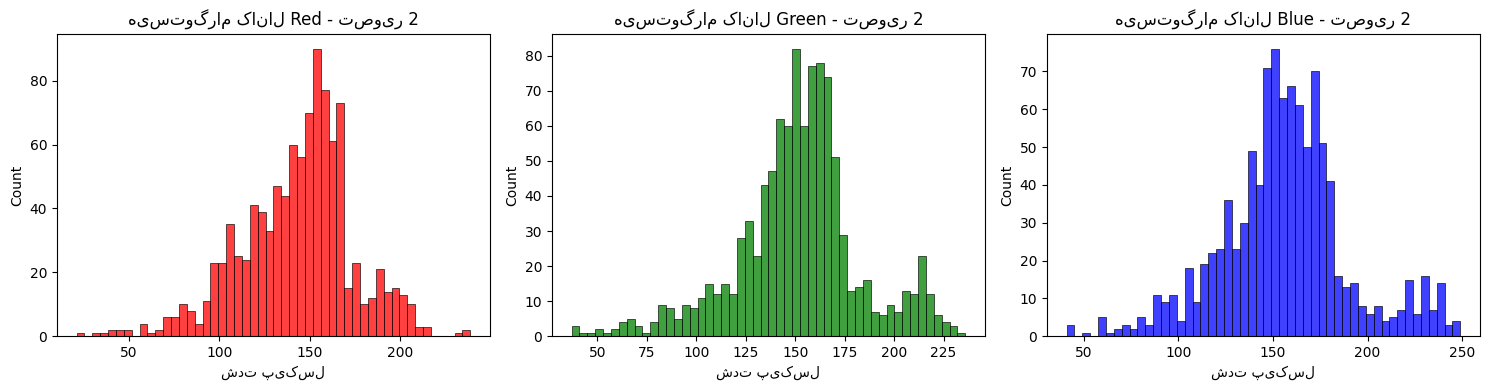

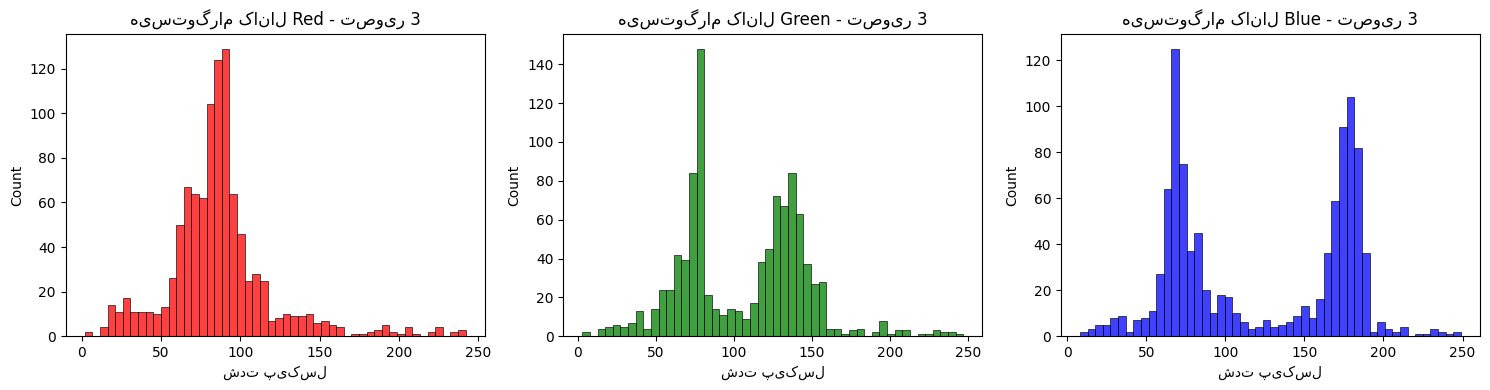

In [11]:
### 3- محاسبه و رسم هیستوگرام شدت پیکسل‌ها برای چند نمونه تصویر
sample_indices = np.random.choice(len(x_all), size=3, replace=False)
sample_images = x_all[sample_indices]

for idx, img in enumerate(sample_images):
    plt.figure(figsize=(15,4))
    for i, color in enumerate(['Red', 'Green', 'Blue']):
        plt.subplot(1,3,i+1)
        sns.histplot(img[:,:,i].flatten(), bins=50, color=color.lower())
        plt.title(f'هیستوگرام کانال {color} - تصویر {idx+1}')
        plt.xlabel('شدت پیکسل')
    plt.tight_layout()
    plt.show()

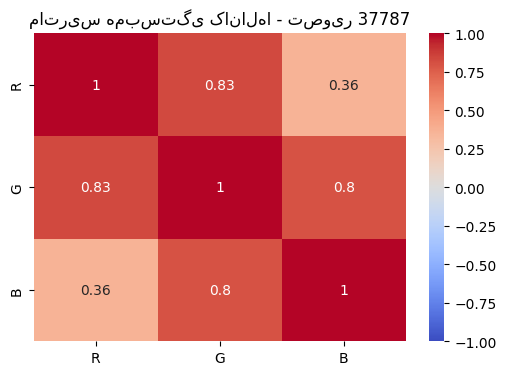

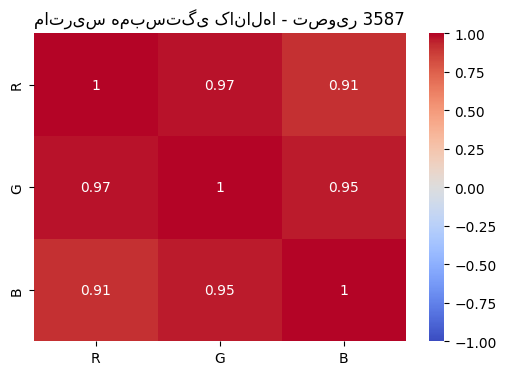

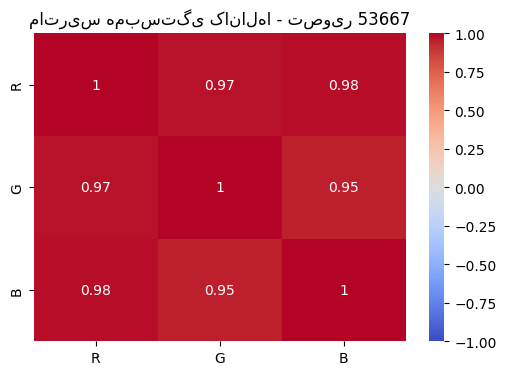

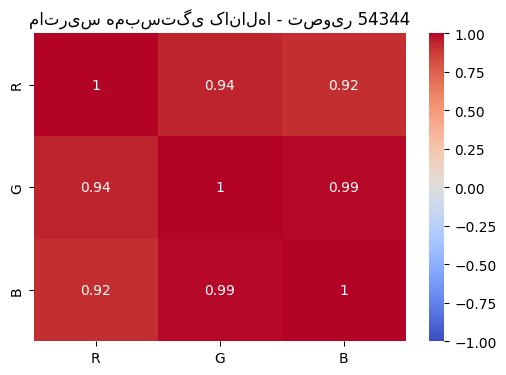

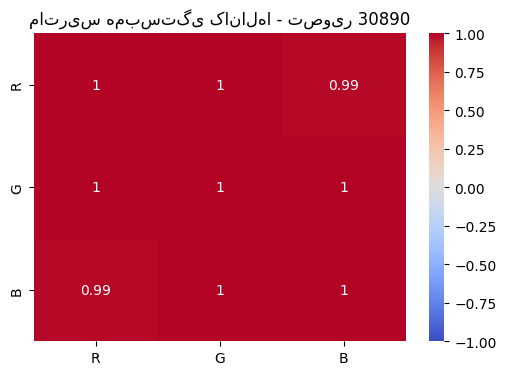

In [12]:
### 4- بررسی همبستگی بین کانال‌ها در تصاویر
# چند نمونه تصویر
sample_indices = np.random.choice(len(x_all), size=5, replace=False)
for idx in sample_indices:
    img = x_all[idx]
    r = img[:,:,0].flatten()
    g = img[:,:,1].flatten()
    b = img[:,:,2].flatten()
    df = pd.DataFrame({'R': r, 'G': g, 'B': b})
    corr = df.corr()
    plt.figure(figsize=(6,4))
    sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title(f'ماتریس همبستگی کانال‌ها - تصویر {idx}')
    plt.show()

C:\Users\MBAhmadi\AppData\Local\Temp\ipykernel_17168\2498018545.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_names, y=class_counts.values, palette="viridis")


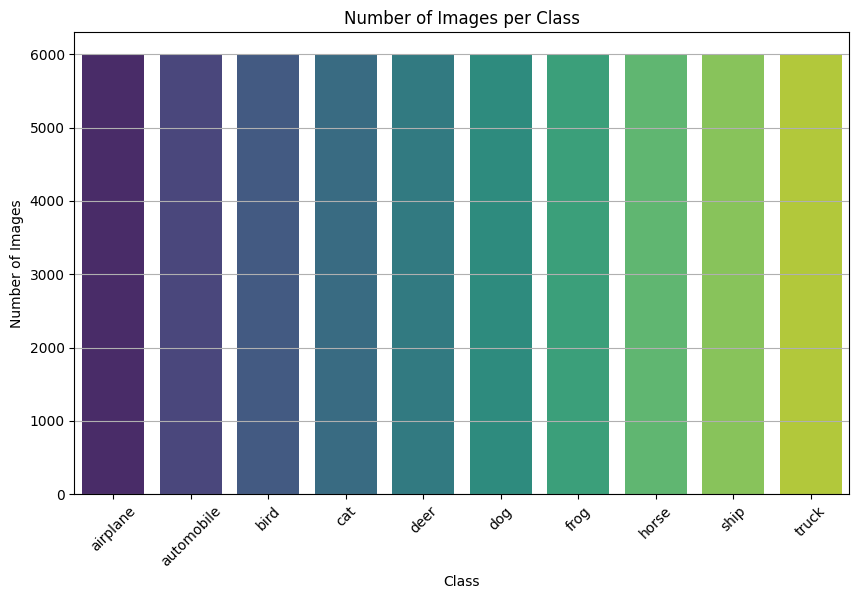

Statistical Summary for Each Color Channel:
                  Red        Green         Blue
Mean       125.426539   123.076746   114.030206
Variance  3966.185615  3851.962383  4449.705189
Skewness     0.118547     0.164506     0.388755
Kurtosis    -0.773513    -0.718915    -0.803610


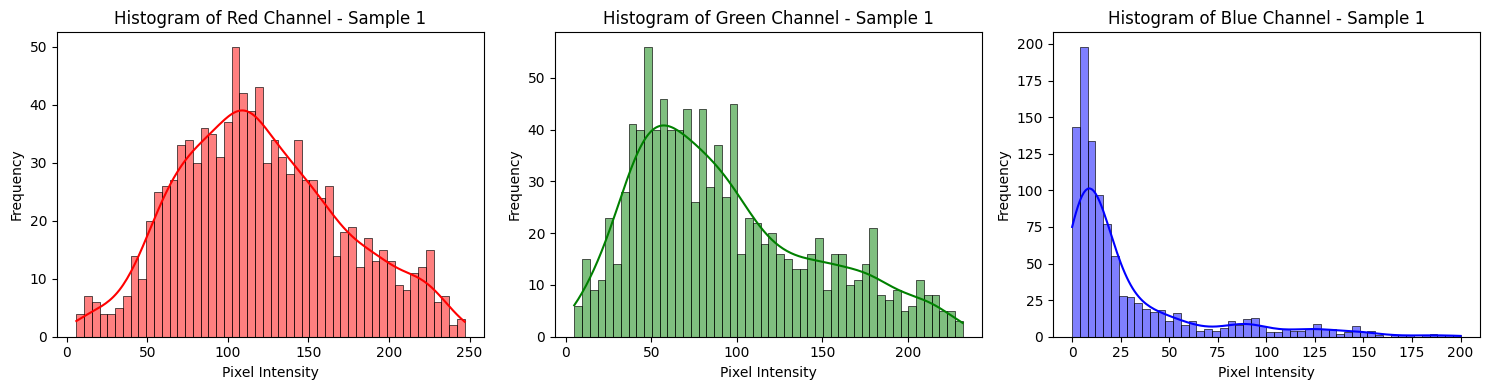

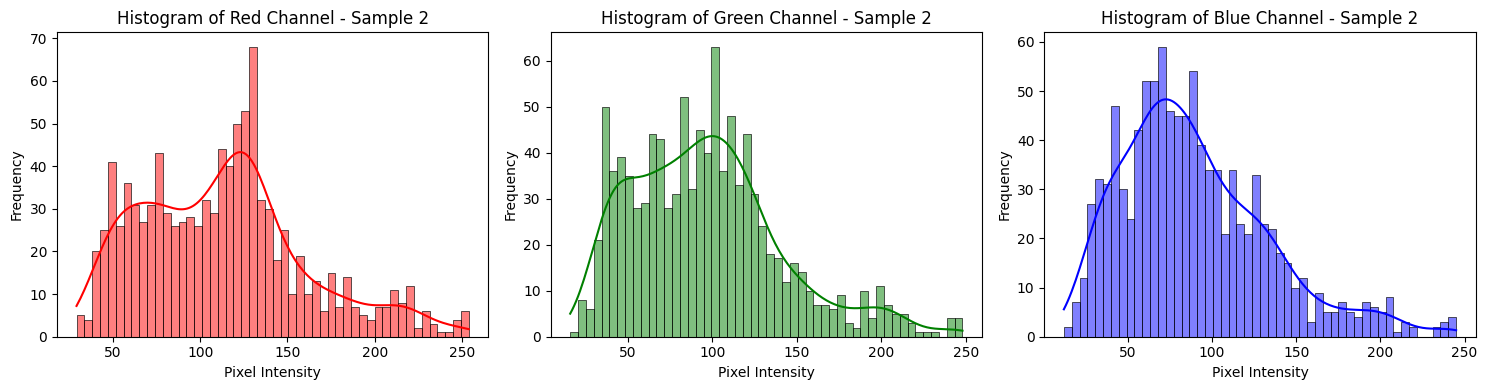

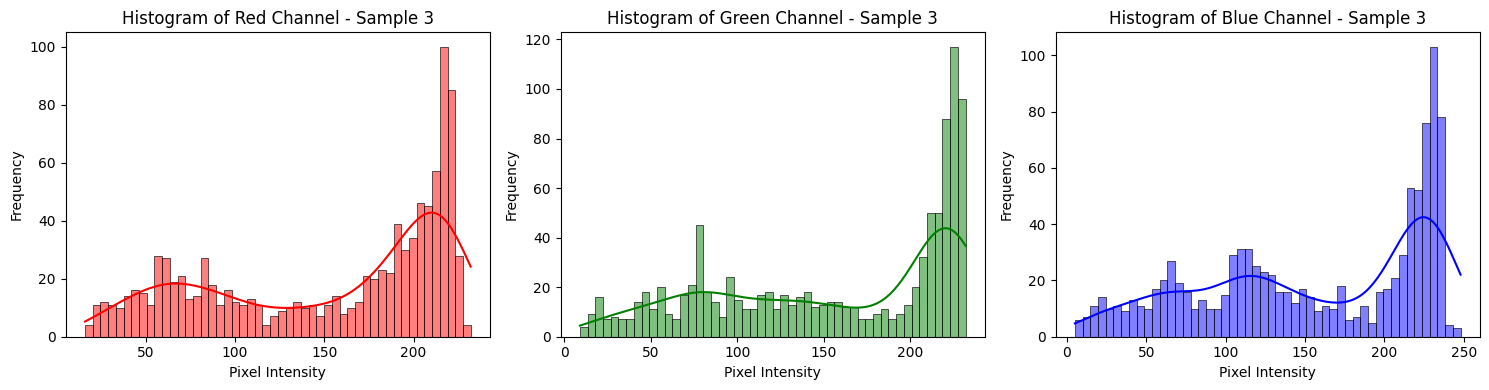

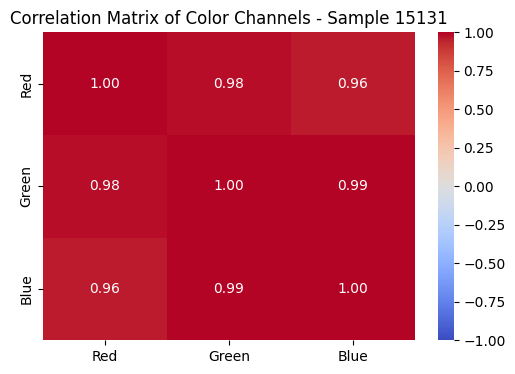

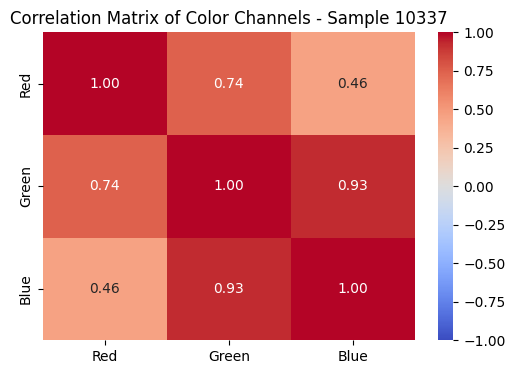

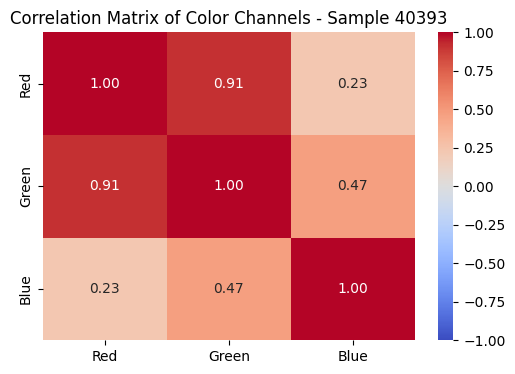

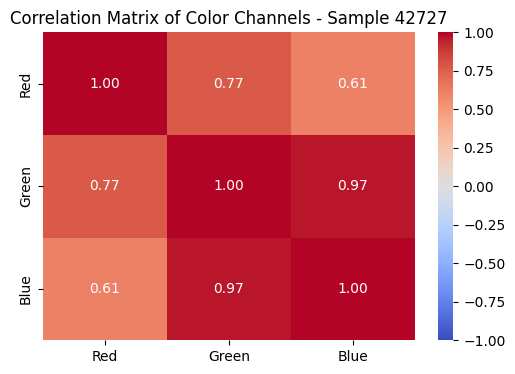

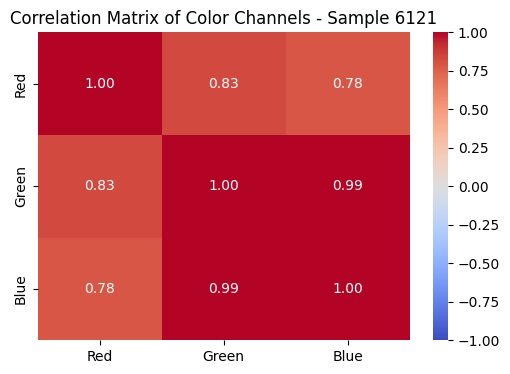

In [13]:
# تحلیل آماری مجموعه داده CIFAR-10
# توضیحات فارسی - نمودارها و عناوین انگلیسی

# نصب کتابخانه‌های مورد نیاز (اگر قبلاً نصب نکردید)
# !pip install tensorflow seaborn matplotlib scipy pandas

# وارد کردن کتابخانه‌ها
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# بارگذاری مجموعه داده CIFAR-10
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# ترکیب داده‌های آموزشی و آزمایشی
x_all = np.concatenate((x_train, x_test), axis=0)
y_all = np.concatenate((y_train, y_test), axis=0).flatten()

# تعریف نام کلاس‌ها
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# -------------------------------
# بخش 1: نمایش تعداد تصاویر در هر کلاس
# -------------------------------

# محاسبه تعداد تصاویر هر کلاس
class_counts = pd.Series(y_all).value_counts().sort_index()

# رسم نمودار
plt.figure(figsize=(10,6))
sns.barplot(x=class_names, y=class_counts.values, palette="viridis")
plt.title('Number of Images per Class')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

# -------------------------------
# بخش 2: محاسبه میانگین، واریانس، چولگی و کشیدگی برای کانال‌های رنگی
# -------------------------------

# استخراج هر کانال رنگی
r_channel = x_all[:,:,:,0]
g_channel = x_all[:,:,:,1]
b_channel = x_all[:,:,:,2]

# محاسبه آمارهای مورد نیاز برای هر کانال
summary = {}
for color, channel in zip(['Red', 'Green', 'Blue'], [r_channel, g_channel, b_channel]):
    flat = channel.flatten()
    summary[color] = {
        'Mean': np.mean(flat),
        'Variance': np.var(flat),
        'Skewness': stats.skew(flat),
        'Kurtosis': stats.kurtosis(flat)
    }

# تبدیل خلاصه به دیتافریم
summary_df = pd.DataFrame(summary)
print("Statistical Summary for Each Color Channel:")
print(summary_df)

# -------------------------------
# بخش 3: رسم هیستوگرام شدت پیکسل‌ها برای چند تصویر
# -------------------------------

# انتخاب چند نمونه تصویر تصادفی
sample_indices = np.random.choice(len(x_all), size=3, replace=False)
sample_images = x_all[sample_indices]

# رسم هیستوگرام برای هر کانال رنگی در هر تصویر
for idx, img in enumerate(sample_images):
    plt.figure(figsize=(15,4))
    for i, color in enumerate(['Red', 'Green', 'Blue']):
        plt.subplot(1,3,i+1)
        sns.histplot(img[:,:,i].flatten(), bins=50, color=color.lower(), kde=True)
        plt.title(f'Histogram of {color} Channel - Sample {idx+1}')
        plt.xlabel('Pixel Intensity')
        plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

# -------------------------------
# بخش 4: بررسی همبستگی بین کانال‌های رنگی
# -------------------------------

# انتخاب چند تصویر تصادفی برای تحلیل همبستگی
sample_indices = np.random.choice(len(x_all), size=5, replace=False)

for idx in sample_indices:
    img = x_all[idx]
    r = img[:,:,0].flatten()
    g = img[:,:,1].flatten()
    b = img[:,:,2].flatten()
    df = pd.DataFrame({'Red': r, 'Green': g, 'Blue': b})
    corr = df.corr()
    
    plt.figure(figsize=(6,4))
    sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
    plt.title(f'Correlation Matrix of Color Channels - Sample {idx}')
    plt.show()


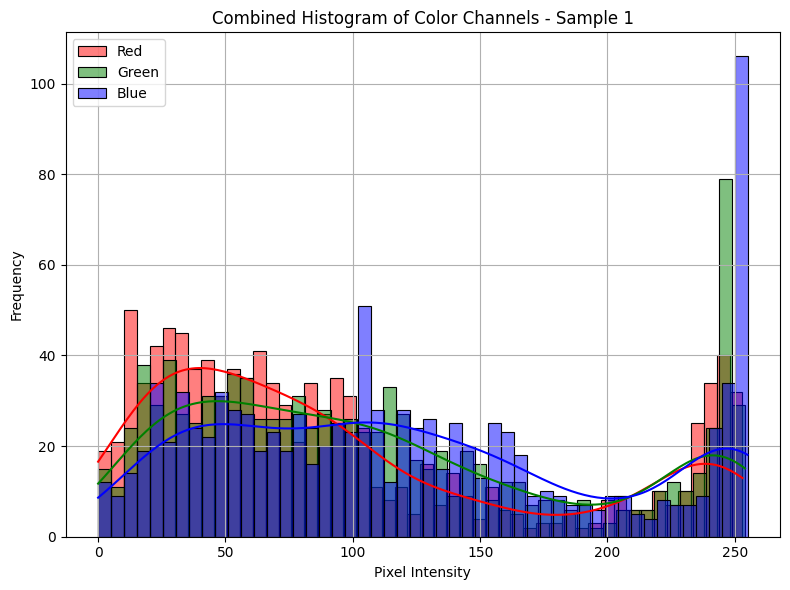

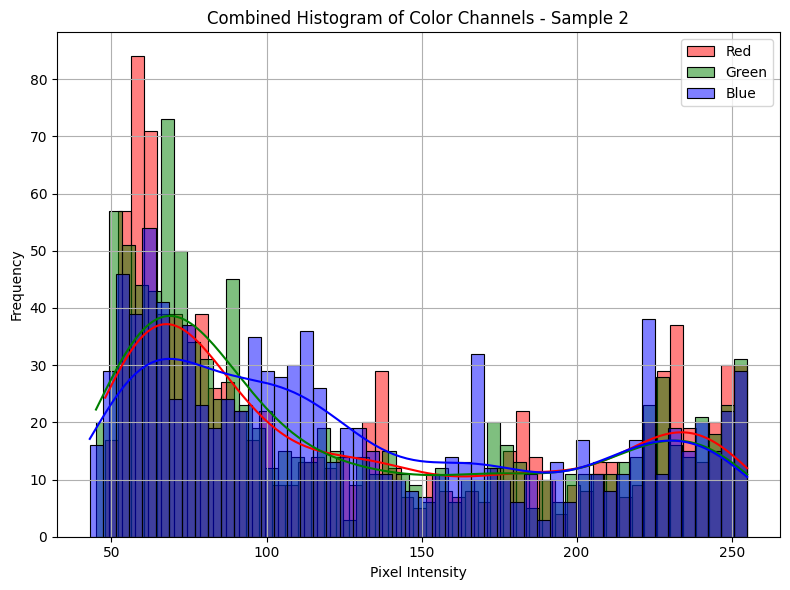

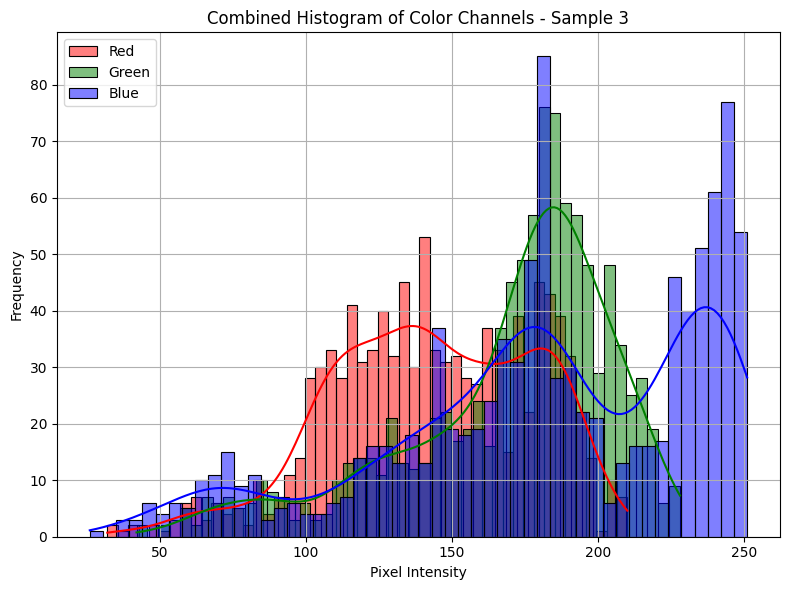

In [14]:
# -------------------------------
# بخش 3: رسم هیستوگرام شدت پیکسل‌ها برای چند تصویر (روی یک نمودار)
# -------------------------------

# انتخاب چند نمونه تصویر تصادفی
sample_indices = np.random.choice(len(x_all), size=3, replace=False)
sample_images = x_all[sample_indices]

# رسم هیستوگرام سه کانال روی یک نمودار برای هر تصویر
for idx, img in enumerate(sample_images):
    plt.figure(figsize=(8,6))
    for i, color in enumerate(['Red', 'Green', 'Blue']):
        sns.histplot(img[:,:,i].flatten(), bins=50, color=color.lower(), kde=True, label=color, alpha=0.5)
    
    plt.title(f'Combined Histogram of Color Channels - Sample {idx+1}')
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


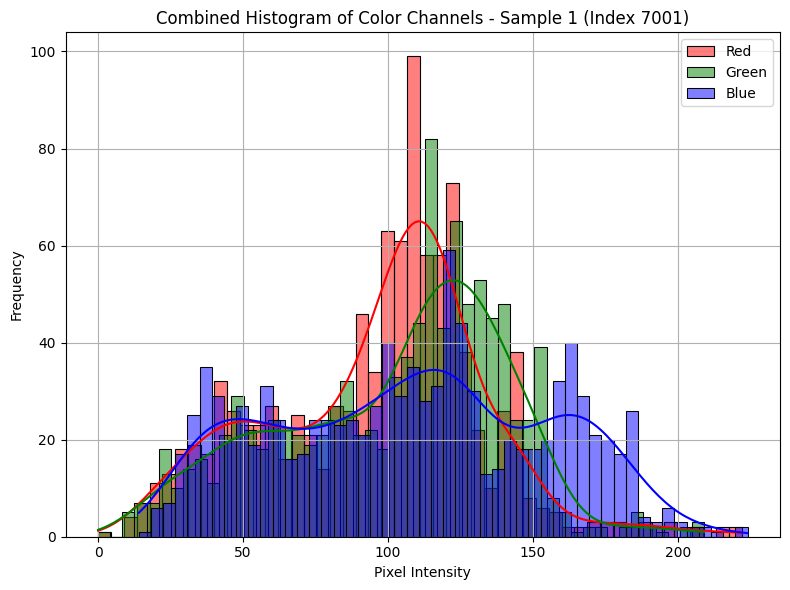

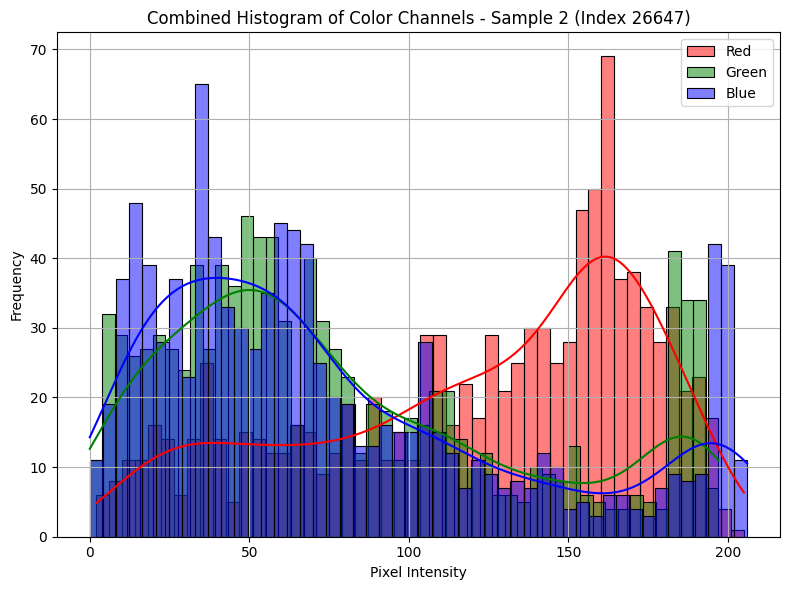

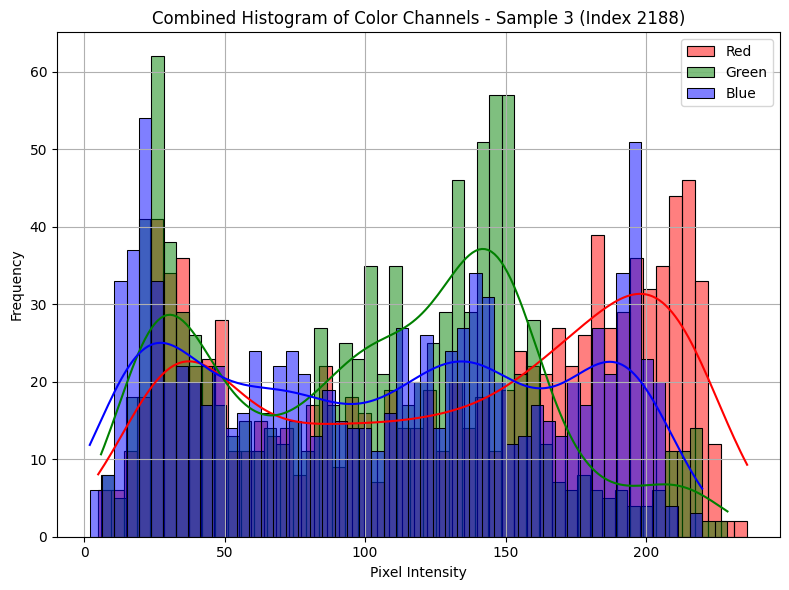

In [16]:
# -------------------------------
# بخش 3: رسم هیستوگرام شدت پیکسل‌ها برای چند تصویر (روی یک نمودار) همراه با شماره نمونه
# -------------------------------

# انتخاب چند نمونه تصویر تصادفی
sample_indices = np.random.choice(len(x_all), size=3, replace=False)
sample_images = x_all[sample_indices]

# رسم هیستوگرام سه کانال روی یک نمودار برای هر تصویر
for idx, sample_idx in enumerate(sample_indices):
    img = x_all[sample_idx]
    plt.figure(figsize=(8,6))
    
    for i, color in enumerate(['Red', 'Green', 'Blue']):
        sns.histplot(img[:,:,i].flatten(), bins=50, color=color.lower(), kde=True, label=color, alpha=0.5)
    
    plt.title(f'Combined Histogram of Color Channels - Sample {idx+1} (Index {sample_idx})')
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


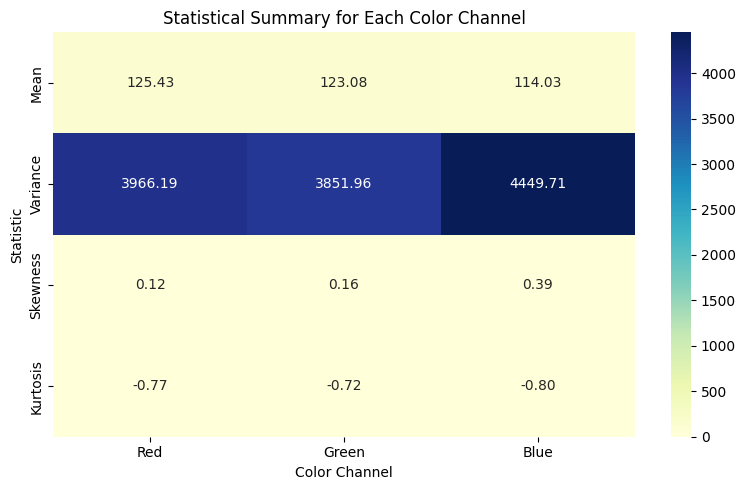

In [18]:
# -------------------------------
# بخش جدید: نمایش خلاصه آماری به صورت تصویری
# -------------------------------

# ترسیم خلاصه آماری با Seaborn به صورت heatmap
plt.figure(figsize=(8,5))
sns.heatmap(summary_df, annot=True, cmap="YlGnBu", fmt=".2f", cbar=True)

plt.title('Statistical Summary for Each Color Channel')
plt.xlabel('Color Channel')
plt.ylabel('Statistic')
plt.tight_layout()
plt.show()


In [19]:
# -------------------------------
# محاسبه آمارهای مورد نیاز برای هر کانال
# -------------------------------

summary = {}
for color, channel in zip(['Red', 'Green', 'Blue'], [r_channel, g_channel, b_channel]):
    flat = channel.flatten()
    summary[color] = {
        'Mean': np.mean(flat),
        'Variance': np.var(flat),
        'Minimum': np.min(flat),
        'Maximum': np.max(flat)
    }

# تبدیل خلاصه به دیتافریم
summary_df = pd.DataFrame(summary)
print("Statistical Summary for Each Color Channel:")
print(summary_df)


Statistical Summary for Each Color Channel:
                  Red        Green         Blue
Mean       125.426539   123.076746   114.030206
Variance  3966.185615  3851.962383  4449.705189
Minimum      0.000000     0.000000     0.000000
Maximum    255.000000   255.000000   255.000000


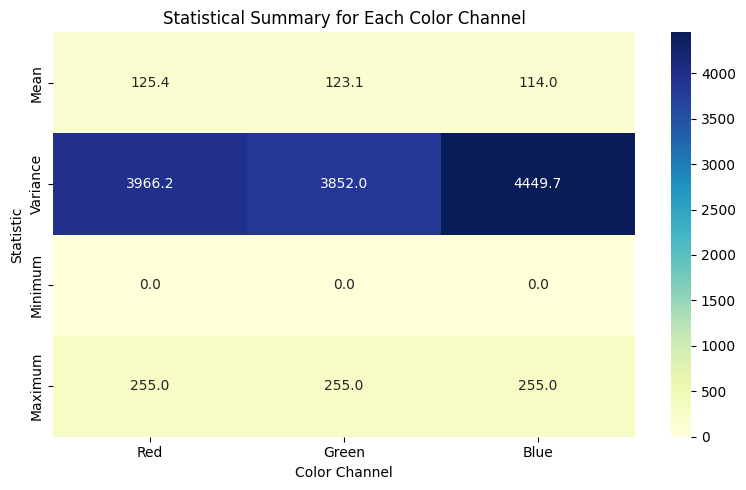

In [20]:
# -------------------------------
# ترسیم خلاصه آماری به صورت تصویری (Heatmap)
# -------------------------------

plt.figure(figsize=(8,5))
sns.heatmap(summary_df, annot=True, cmap="YlGnBu", fmt=".1f", cbar=True)

plt.title('Statistical Summary for Each Color Channel')
plt.xlabel('Color Channel')
plt.ylabel('Statistic')
plt.tight_layout()
plt.show()
